  **EEG Sleep Stage Classification — Pipeline
  Zekriyapanah Gashti & Farjamnia (2025) as references | arXiv:2510.07524**


* STEP 1 : Discover all SC4* PSG/Hypnogram pairs
* STEP 2 : Load + preprocess raw EDF → 30-second epochs
* STEP 3 : CWT (Morlet) feature extraction per frequency band + other features
* STEP 4 : XGBoost classifier with 5-fold stratified CV
* STEP 5 : Evaluation + plots (scalograms, confusion matrix,
            feature importance)

In [ ]:
# Imports
import os, glob, re, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Patch
import pywt
import mne

from scipy.signal import welch
from scipy import stats
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, f1_score, cohen_kappa_score,
                             precision_score, recall_score)

from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
import joblib

import xgboost as xgb

warnings.filterwarnings('ignore')
mne.set_log_level('WARNING')

In [ ]:
# 0.  CONFIGURATION  ← only change DATA_DIR

DATA_DIR = '.\sleep-cassette'
OUT_DIR  = '.\outputs'
os.makedirs(OUT_DIR, exist_ok=True)

CHANNEL   = 'EEG Fpz-Cz'   # primary channel used in the paper
SFREQ     = 100             # resample target (Hz)
EPOCH_SEC = 30              # standard sleep epoch length

# Sleep stage label mapping  (AASM via Sleep-EDF annotations)
STAGE_MAP = {
    'Sleep stage W' : 0,
    'Sleep stage 1' : 1,
    'Sleep stage 2' : 2,
    'Sleep stage 3' : 3,
    'Sleep stage 4' : 3,   # N3 = SWS (merge 3+4 → N3, AASM)
    'Sleep stage R' : 4,
    'Sleep stage ?' : -1,  # unknown → excluded
    'Movement time' : -1,  # movement → excluded
}
STAGE_NAMES = {0:'Wake', 1:'N1', 2:'N2', 3:'N3', 4:'REM'}
COLORS      = {0:'#E24B4A', 1:'#EF9F27', 2:'#378ADD',
               3:'#1D9E75', 4:'#7F77DD'}

# CWT / frequency band settings
WAVELET    = 'morl'
FREQ_BANDS = {
    'delta' : (0.5,  4.0),
    'theta' : (4.0,  8.0),
    'alpha' : (8.0, 13.0),
    'sigma' : (12.0,15.0),
    'beta'  : (13.0,30.0),
}


In [25]:
# DISCOVER ALL PSG / HYPNOGRAM PAIRS

print(" Discovering EDF file pairs")

# PSG files:        SC4??1E0-PSG.edf  (or SC4??2E0-PSG.edf)
# Hypnogram files:  SC4??1EH-Hypnogram.edf
psg_files  = sorted(glob.glob(os.path.join(DATA_DIR, '*-PSG.edf')))
hyp_files  = sorted(glob.glob(os.path.join(DATA_DIR, '*-Hypnogram.edf')))

def subject_id(path):
    """Extract subject/night code, e.g. SC4011 from SC4011E0-PSG.edf"""
    fname = os.path.basename(path)
    # Take first 6 characters: SC + 4-digit code
    return fname[:6]

# Build a dict: subject_id → (psg_path, hyp_path)
psg_dict = {subject_id(p): p for p in psg_files}
hyp_dict = {subject_id(h): h for h in hyp_files}

pairs = []
for sid in sorted(psg_dict.keys()):
    if sid in hyp_dict:
        pairs.append((sid, psg_dict[sid], hyp_dict[sid]))
    else:
        print(f"No hypnogram found for {sid}, skipping")

print(f"\n  Found {len(pairs)} matched PSG–Hypnogram pairs:")
for sid, psg, hyp in pairs:
    print(f"    {sid}  →  {os.path.basename(psg)}"
          f"  +  {os.path.basename(hyp)}")

 Discovering EDF file pairs

  Found 153 matched PSG–Hypnogram pairs:
    SC4001  →  SC4001E0-PSG.edf  +  SC4001EC-Hypnogram.edf
    SC4002  →  SC4002E0-PSG.edf  +  SC4002EC-Hypnogram.edf
    SC4011  →  SC4011E0-PSG.edf  +  SC4011EH-Hypnogram.edf
    SC4012  →  SC4012E0-PSG.edf  +  SC4012EC-Hypnogram.edf
    SC4021  →  SC4021E0-PSG.edf  +  SC4021EH-Hypnogram.edf
    SC4022  →  SC4022E0-PSG.edf  +  SC4022EJ-Hypnogram.edf
    SC4031  →  SC4031E0-PSG.edf  +  SC4031EC-Hypnogram.edf
    SC4032  →  SC4032E0-PSG.edf  +  SC4032EP-Hypnogram.edf
    SC4041  →  SC4041E0-PSG.edf  +  SC4041EC-Hypnogram.edf
    SC4042  →  SC4042E0-PSG.edf  +  SC4042EC-Hypnogram.edf
    SC4051  →  SC4051E0-PSG.edf  +  SC4051EC-Hypnogram.edf
    SC4052  →  SC4052E0-PSG.edf  +  SC4052EC-Hypnogram.edf
    SC4061  →  SC4061E0-PSG.edf  +  SC4061EC-Hypnogram.edf
    SC4062  →  SC4062E0-PSG.edf  +  SC4062EC-Hypnogram.edf
    SC4071  →  SC4071E0-PSG.edf  +  SC4071EC-Hypnogram.edf
    SC4072  →  SC4072E0-PSG.edf  +  SC4072EH-

In [26]:
#  LOAD + PREPROCESS ALL PAIRS → EPOCHS

print(" \n Loading & epoching raw EDF files")


def load_psg_hypnogram(psg_path, hyp_path,
                       channel=CHANNEL, sfreq=SFREQ,
                       epoch_sec=EPOCH_SEC,
                       wake_buffer_epochs=60):
    """
    Load one PSG + Hypnogram EDF pair.
    Load one PSG + Hypnogram pair with full preprocessing.

    Pipeline:
      1. Load EDF, pick Fpz-Cz channel
      2. Resample to sfreq (100 Hz)
      3. Bandpass filter 0.5–40 Hz
      4. Build label array — epochs never covered by any annotation → -1
      5. Trim excessive Wake: keep wake_buffer_epochs on each side of sleep
         Wake epochs INSIDE the sleep period are preserved as-is
      6. Drop all epochs with label == -1 (unknown / unannotated / movement)

    Returns
    -------
    epochs : np.ndarray  shape (n_valid, n_samples)  float32  — µV
    labels : np.ndarray  shape (n_valid,)            int  0-4, -1 excluded

    Wake trimming
    -------------
    Keeps wake_buffer_epochs (default 60 = 30 min) of Wake before the
    first and after the last non-Wake sleep epoch. Wake epochs that
    appear INSIDE the sleep period (arousals) are preserved as-is.
    Only epochs labelled -1 (movement / unknown / unannotated) are dropped.
    """
    # ── Load PSG ──────────────────────────────────────────
    raw = mne.io.read_raw_edf(psg_path, preload=True, verbose=False)

    # Pick the Fpz-Cz channel (primary channel in the paper)
    if channel not in raw.ch_names:
        eeg_chs = [c for c in raw.ch_names if 'EEG' in c.upper()]
        if not eeg_chs:
            raise ValueError(f"Channel '{channel}' not found in "
                             f"{psg_path}. Available: {raw.ch_names}")
        channel = eeg_chs[0]
        print(f" Falling back to channel: {channel}")

    raw.pick_channels([channel])

    # Resample to SFREQ (100 Hz)
    if raw.info['sfreq'] != sfreq:
        raw.resample(sfreq, npad='auto')

    # Band-pass filter 0.5 – 40 Hz (standard preprocessing)
    raw.filter(0.5, 40.0, fir_window='hamming', verbose=False)

    data = raw.get_data()[0] * 1e6    # → µV, shape: (n_samples_total,)

    # ── Load Hypnogram annotations ────────────────────────
    ann = mne.read_annotations(hyp_path)

    # Build label array aligned to 30-second epochs
    n_samples_per_epoch = int(epoch_sec * sfreq)
    n_epochs_total      = len(data) // n_samples_per_epoch

    # Fill label array (default -1 = unknown/unannotated)
    label_arr = np.full(n_epochs_total, -1, dtype=np.int32)

    for onset, duration, description in zip(
            ann.onset, ann.duration, ann.description):
        stage = STAGE_MAP.get(description, -1)
        start_epoch = int(onset // epoch_sec)
        n_ep        = max(1, int(round(duration / epoch_sec)))
        for ep in range(start_epoch, min(start_epoch + n_ep,
                                         n_epochs_total)):
            label_arr[ep] = stage

    # ── Trim excessive Wake ───────────────────────────────
    # Boundaries defined by first/last N1/N2/N3/REM epoch.
    # Everything between those boundaries is kept intact,
    # including any Wake arousals mid-recording.
    sleep_mask   = (label_arr >= 1) & (label_arr <= 4)
    sleep_epochs = np.where(sleep_mask)[0]

    if len(sleep_epochs) == 0:
        print(f"  [warn] No sleep epochs found, skipping {psg_path}")
        return (np.empty((0, n_samples_per_epoch), dtype=np.float32),
                np.empty((0,), dtype=np.int32))

    sleep_start = sleep_epochs[0]
    sleep_end   = sleep_epochs[-1]

    trim_start = max(0, sleep_start - wake_buffer_epochs)
    trim_end   = min(n_epochs_total, sleep_end + wake_buffer_epochs + 1)

    label_arr = label_arr[trim_start : trim_end]
    data      = data[trim_start * n_samples_per_epoch :
                     trim_end   * n_samples_per_epoch]

    # ── Slice into 30-second epochs ───────────────────────
    # label == -1 covers: movement, '?', and unannotated gaps.
    # Wake (0) is intentionally kept.
    n_trimmed   = len(label_arr)
    epochs_list = []
    labels_list = []
    for i in range(n_trimmed):
        lbl = label_arr[i]
        if lbl == -1:
            continue                  # skip unknown/movement/unannotated
        segment = data[i * n_samples_per_epoch :
                       (i + 1) * n_samples_per_epoch]
        epochs_list.append(segment)
        labels_list.append(lbl)

    return (np.array(epochs_list, dtype=np.float32),
            np.array(labels_list, dtype=np.int32))


# Load all pairs
all_epochs, all_labels, all_sids = [], [], []

for idx, (sid, psg_path, hyp_path) in enumerate(pairs):
    print(f"\n  [{idx+1}/{len(pairs)}] Loading {sid} ...", end=' ')
    try:
        ep, lb = load_psg_hypnogram(psg_path, hyp_path)

        if len(ep) == 0:
            print("  skipped (no valid epochs)")
            continue

        all_epochs.append(ep)
        all_labels.append(lb)
        # one subject ID per epoch — same length as ep
        all_sids.append(np.array([sid] * len(ep)))

        stage_counts = {STAGE_NAMES[s]: int((lb==s).sum())
                        for s in range(5) if (lb==s).sum() > 0}
        print(f"{len(ep)} epochs  →  {stage_counts}")
    except Exception as e:
        print(f"\n    ✗ Error: {e}")

epochs = np.concatenate(all_epochs, axis=0)
labels = np.concatenate(all_labels, axis=0)
sids   = np.concatenate(all_sids,   axis=0)   # shape: (n_epochs,)  dtype: str

print(f"\n  ─────────────────────────────────────────────")
print(f"  Total epochs : {epochs.shape}  "
      f"(shape: n_epochs × {epochs.shape[1]} samples)")
print(f"  Total labels : {labels.shape}")
print(f"  Total sids   : {sids.shape}  —  {len(np.unique(sids))} unique subjects")
print(f"  Class distribution:")
for s in range(5):
    cnt = (labels == s).sum()
    pct = 100 * cnt / len(labels)
    print(f"    {STAGE_NAMES[s]:5s} (class {s}): "
          f"{cnt:5d}  ({pct:.1f}%)")

# Save preprocessed arrays
np.save(os.path.join(OUT_DIR, 'epochs.npy'), epochs)
np.save(os.path.join(OUT_DIR, 'labels.npy'), labels)
np.save(os.path.join(OUT_DIR, 'sids.npy'),   sids)
print(f"\n  Saved preprocessed data → {OUT_DIR}")

 
 Loading & epoching raw EDF files

  [1/153] Loading SC4001 ... 841 epochs  →  {'Wake': 188, 'N1': 58, 'N2': 250, 'N3': 220, 'REM': 125}

  [2/153] Loading SC4002 ... 1127 epochs  →  {'Wake': 183, 'N1': 59, 'N2': 373, 'N3': 297, 'REM': 215}

  [3/153] Loading SC4011 ... 1103 epochs  →  {'Wake': 157, 'N1': 109, 'N2': 562, 'N3': 105, 'REM': 170}

  [4/153] Loading SC4012 ... 1186 epochs  →  {'Wake': 162, 'N1': 92, 'N2': 660, 'N3': 96, 'REM': 176}

  [5/153] Loading SC4021 ... 1025 epochs  →  {'Wake': 128, 'N1': 94, 'N2': 545, 'N3': 95, 'REM': 163}

  [6/153] Loading SC4022 ... 1009 epochs  →  {'Wake': 125, 'N1': 184, 'N2': 402, 'N3': 119, 'REM': 179}

  [7/153] Loading SC4031 ... 952 epochs  →  {'Wake': 140, 'N1': 61, 'N2': 485, 'N3': 57, 'REM': 209}

  [8/153] Loading SC4032 ... 911 epochs  →  {'Wake': 136, 'N1': 45, 'N2': 400, 'N3': 131, 'REM': 199}

  [9/153] Loading SC4041 ... 1235 epochs  →  {'Wake': 200, 'N1': 166, 'N2': 620, 'N3': 53, 'REM': 196}

  [10/153] Loading SC4042 ... 1

In [ ]:
#   CWT FEATURE EXTRACTION

print(" \n STEP 3 — CWT Feature Extraction (Morlet wavelet)")


def compute_cwt_features(epoch, sfreq=SFREQ, wavelet=WAVELET):
    """
    Apply CWT to one 30-s epoch and extract statistical features
    per EEG frequency band.

    Features per band (8 stats × 5 bands = 40):
      mean, std, energy, spectral-entropy,
      skewness, kurtosis, max, min

    Time-domain features (8):
      zero-crossing rate, RMS, mean-absolute-value,
      waveform length, log-variance,
      Hjorth activity, mobility, complexity

    Frequency-domain features (4):
      relative spectral power — delta, theta, alpha, beta  (Welch PSD)

    Total: 40 + 8 + 4 = 52 features per epoch
    """
    dt           = 1.0 / sfreq
    central_freq = pywt.central_frequency(wavelet)

    # Scales covering 0.5 – 30 Hz
    scale_max = central_freq / (0.5  * dt)
    scale_min = central_freq / (30.0 * dt)
    scales    = np.geomspace(scale_min, scale_max, num=64)

    coeffs, freqs = pywt.cwt(epoch, scales, wavelet,
                             sampling_period=dt)
    power = np.abs(coeffs) ** 2          # (64, n_time)

    features = []

    # ── Per-band CWT statistical features (40) ────────────
    for band_name, (flo, fhi) in FREQ_BANDS.items():
        mask = (freqs >= flo) & (freqs <= fhi)
        if mask.sum() == 0:
            features.extend([0.0] * 8)
            continue

        band_power = power[mask, :].mean(axis=0)   # (n_time,)
        bp_sum     = band_power.sum() + 1e-12

        features.extend([
            np.mean(band_power),
            np.std(band_power),
            np.sum(band_power),                     # energy
            -np.sum((band_power / bp_sum) *
                    np.log(band_power / bp_sum + 1e-12)),  # entropy
            float(stats.skew(band_power)),
            float(stats.kurtosis(band_power)),
            np.max(band_power),
            np.min(band_power),
        ])

    # ── Time-domain features (8) ──────────────────────────
    d1       = np.diff(epoch)
    d2       = np.diff(d1)
    activity = np.var(epoch)

    features.extend([
        ((np.diff(np.sign(epoch)) != 0).sum()) / len(epoch),  # ZCR
        np.sqrt(np.mean(epoch ** 2)),                          # RMS
        np.mean(np.abs(epoch)),                                # MAV
        np.sum(np.abs(d1)),                                    # waveform length
        np.log(activity + 1e-12),                             # log-variance
        # ── Hjorth parameters (paper section 3.3.i) ───────
        activity,                                              # activity
        np.sqrt(np.var(d1) / (activity      + 1e-12)),        # mobility
        (np.sqrt(np.var(d2) / (np.var(d1)   + 1e-12)) /
         (np.sqrt(np.var(d1) / (activity    + 1e-12)) + 1e-12)),  # complexity
    ])

    # ── Frequency-domain relative spectral power (4) ──────
    # Welch PSD — independent from CWT, pure frequency-domain estimate
    freqs_w, psd = welch(epoch, fs=sfreq, nperseg=sfreq * 4)
    total_power  = psd.sum() + 1e-12
    for flo, fhi in FREQ_BANDS.values():
        mask_w = (freqs_w >= flo) & (freqs_w <= fhi)
        features.append(psd[mask_w].sum() / total_power)      # relative power

    return np.array(features, dtype=np.float32)


# ── Feature names (for importance plot) ───────────────────
feature_names = []
for band in FREQ_BANDS:
    for stat in ['mean', 'std', 'energy', 'entropy',
                 'skew', 'kurt', 'max', 'min']:
        feature_names.append(f'{band}_{stat}')

feature_names += [
    'zcr', 'rms', 'mav', 'wl', 'log_var',          # time-domain
    'hjorth_activity', 'hjorth_mobility',             # Hjorth
    'hjorth_complexity',
]
feature_names += [f'{band}_relpower' for band in FREQ_BANDS]  # Welch

assert len(feature_names) == 53, f"Expected 53, got {len(feature_names)}"

print(f"  Extracting features from {len(epochs)} epochs "
      f"({len(feature_names)} features each)...")
print(f"  (CWT is O(scales × n_time) — expect ~1 min per 800 epochs)")

X_features = []
for i, epoch in enumerate(epochs):
    if i % 50 == 0:
        print(f"    {i}/{len(epochs)} epochs processed...", end='\r')
    X_features.append(compute_cwt_features(epoch))

X      = np.array(X_features)
y      = labels.copy()
groups = sids.copy()       # patient ID per epoch — for GroupShuffleSplit

print(f"\n  Feature matrix : {X.shape}  ✓")
print(f"  Labels         : {y.shape}  ✓")
print(f"  Groups (sids)  : {groups.shape}  — {len(np.unique(groups))} unique subjects  ✓")

# Save so you can skip re-extraction on future runs
np.save(os.path.join(OUT_DIR, 'X_features.npy'), X)
np.save(os.path.join(OUT_DIR, 'y_labels.npy'),   y)
np.save(os.path.join(OUT_DIR, 'groups_sids.npy'), groups)
print(f"  Saved features → {OUT_DIR}")

 
 STEP 3 — CWT Feature Extraction (Morlet wavelet)
  Extracting features from 195469 epochs (53 features each)...
  (CWT is O(scales × n_time) — expect ~1 min per 800 epochs)
    195450/195469 epochs processed...
  Feature matrix : (195469, 53)  ✓
  Labels         : (195469,)  ✓
  Groups (sids)  : (195469,)  — 153 unique subjects  ✓
  Saved features → .\outputs


---
Preprocessing Visualisation
Before/after wake trimming for one example subject, plus the full-dataset class distribution.

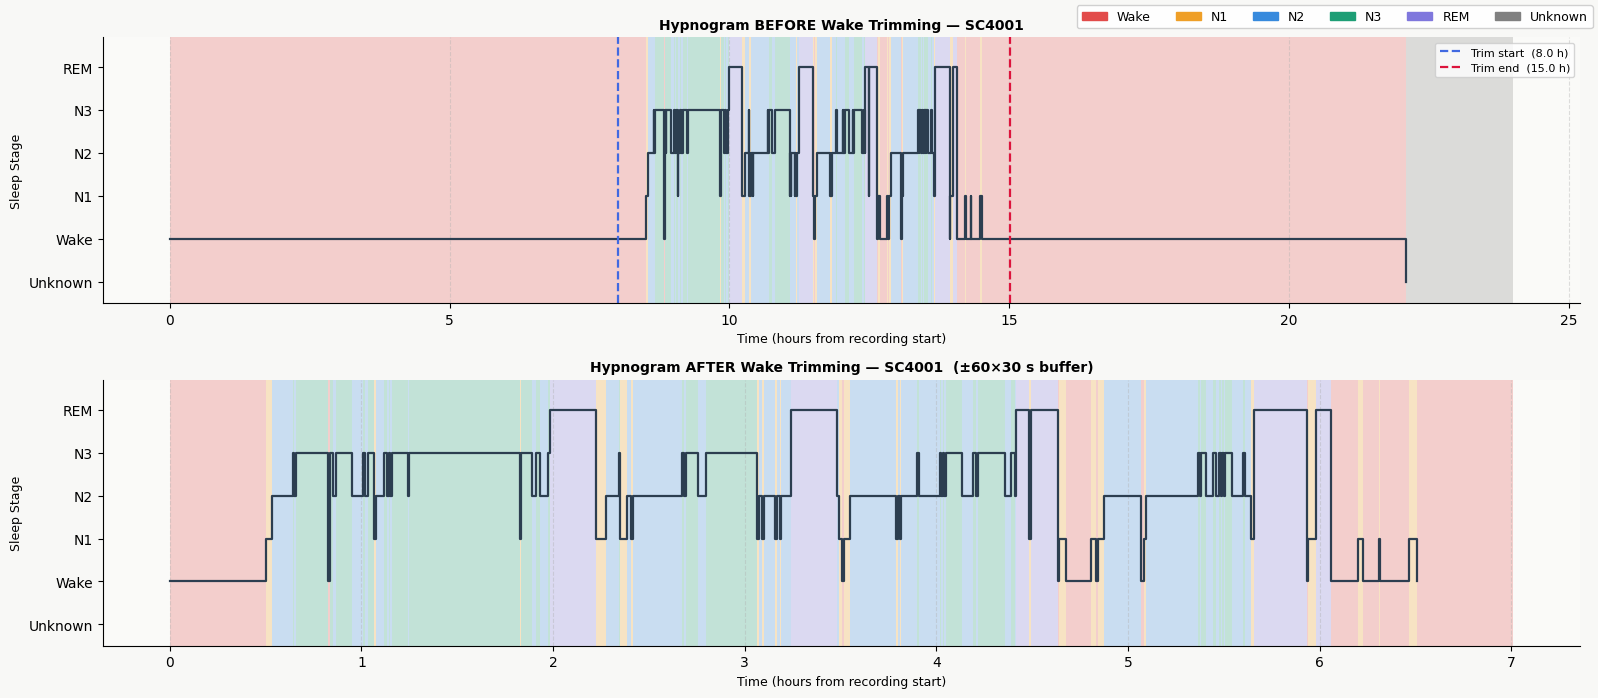

Saved → EEG_Signal_before_after_trim.png
  Trim window: 8.01 h → 15.02 h  (7.01 h kept of 24.00 h total)


In [ ]:
# ── Hypnogram BEFORE & AFTER Wake Trimming — Subject SC4001 ────────────────

stage_map_plot = {
    'Sleep stage W':  0,
    'Sleep stage 1':  1,
    'Sleep stage 2':  2,
    'Sleep stage 3':  3,
    'Sleep stage 4':  3,
    'Sleep stage R':  4,
    'Sleep stage ?': -1,
}
stage_colors_num = {
    0: '#E24B4A',
    1: '#EF9F27',
    2: '#378ADD',
    3: '#1D9E75',
    4: '#7F77DD',
    -1: 'gray',
}
STAGE_NAMES_PLOT = {0:'Wake', 1:'N1', 2:'N2', 3:'N3', 4:'REM', -1:'Unknown'}

# ── Load first SC4001 pair ───────────────────────────────────────────────────
ex_psg = next(p for _, p, _ in pairs if 'SC4001' in p)
ex_hyp = next(h for _, _, h in pairs if 'SC4001' in h)

annot_ex = mne.read_annotations(ex_hyp)
raw_ex   = mne.io.read_raw_edf(ex_psg, preload=False, verbose=False)

df_before = pd.DataFrame({
    'onset_sec':   annot_ex.onset,
    'duration':    annot_ex.duration,
    'description': annot_ex.description,
})
df_before['stage_num'] = df_before['description'].map(stage_map_plot).fillna(-1).astype(int)
df_before['onset_hr']  = df_before['onset_sec'] / 3600
df_before['end_hr']    = (df_before['onset_sec'] + df_before['duration']) / 3600

# ── Compute trim boundaries (mirrors load_psg_hypnogram logic) ───────────────
WAKE_BUF  = 60                                      # ± 30-min wake buffer
n_total   = int(raw_ex.n_times) // int(EPOCH_SEC * SFREQ)
lbl_arr   = np.full(n_total, -1, dtype=np.int32)

for _o, _d, _desc in zip(annot_ex.onset, annot_ex.duration, annot_ex.description):
    _st = STAGE_MAP.get(_desc, -1)
    _se = int(_o // EPOCH_SEC)
    for _ep in range(_se, min(_se + max(1, int(round(_d / EPOCH_SEC))), n_total)):
        lbl_arr[_ep] = _st

sleep_ep  = np.where((lbl_arr >= 1) & (lbl_arr <= 4))[0]
trim_s_ep = max(0, sleep_ep[0]  - WAKE_BUF)
trim_e_ep = min(n_total, sleep_ep[-1] + WAKE_BUF + 1)
trim_s_hr = trim_s_ep * EPOCH_SEC / 3600
trim_e_hr = trim_e_ep * EPOCH_SEC / 3600

# ── Build after-trim DataFrame ───────────────────────────────────────────────
max_after_hr = trim_e_hr - trim_s_hr

df_after = df_before[
    (df_before['end_hr'] > trim_s_hr) & (df_before['onset_hr'] < trim_e_hr)
].copy()
df_after['onset_hr'] = (df_after['onset_hr'] - trim_s_hr).clip(lower=0)
df_after['end_hr']   = (df_after['end_hr']   - trim_s_hr).clip(lower=0,
                                                                upper=max_after_hr)

# ── Plot helper ──────────────────────────────────────────────────────────────
def _plot_hyp(df, title, ax, trim_lines=None):
    df_s = df.sort_values('onset_hr').reset_index(drop=True)

    # ── Color each annotation by its stage ──────────────────────────────────
    for _, row in df_s.iterrows():
        color = stage_colors_num.get(int(row['stage_num']), 'gray')
        ax.axvspan(row['onset_hr'], row['end_hr'],
                   alpha=0.25, color=color, linewidth=0)

    # ── Step line ────────────────────────────────────────────────────────────
    ax.step(df_s['onset_hr'], df_s['stage_num'],
            where='post', color='#2c3e50', linewidth=1.6)

    if trim_lines:
        ax.axvline(trim_lines[0], color='royalblue', lw=1.6, ls='--',
                   label=f'Trim start  ({trim_lines[0]:.1f} h)')
        ax.axvline(trim_lines[1], color='crimson',   lw=1.6, ls='--',
                   label=f'Trim end  ({trim_lines[1]:.1f} h)')
        ax.legend(fontsize=8, loc='upper right')

    ax.set_yticks([-1, 0, 1, 2, 3, 4])
    ax.set_yticklabels(['Unknown', 'Wake', 'N1', 'N2', 'N3', 'REM'])
    ax.set_ylim(-1.5, 4.7)
    ax.set_xlabel('Time (hours from recording start)', fontsize=9)
    ax.set_ylabel('Sleep Stage', fontsize=9)
    ax.set_title(title, fontweight='bold', fontsize=10)
    ax.spines[['top', 'right']].set_visible(False)
    ax.grid(axis='x', linestyle='--', alpha=0.4)
    ax.set_facecolor('#fafaf8')

# ── Figure 1 : BEFORE / AFTER side-by-side ──────────────────────────────────
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 7))
fig.patch.set_facecolor('#f8f8f6')

_plot_hyp(df_before,
          'Hypnogram BEFORE Wake Trimming — SC4001',
          ax1, trim_lines=(trim_s_hr, trim_e_hr))

_plot_hyp(df_after,
          f'Hypnogram AFTER Wake Trimming — SC4001  (±{WAKE_BUF}×30 s buffer)',
          ax2)

patches = [mpatches.Patch(color=stage_colors_num[k], label=STAGE_NAMES_PLOT[k])
           for k in [0, 1, 2, 3, 4, -1]]
fig.legend(handles=patches, ncol=6, fontsize=9, loc='upper right', framealpha=0.9)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'EEG_Signal_before_after_trim.png'),
            dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print(f"Saved → EEG_Signal_before_after_trim.png")
print(f"  Trim window: {trim_s_hr:.2f} h → {trim_e_hr:.2f} h  "
      f"({trim_e_hr - trim_s_hr:.2f} h kept of {df_before['end_hr'].max():.2f} h total)")


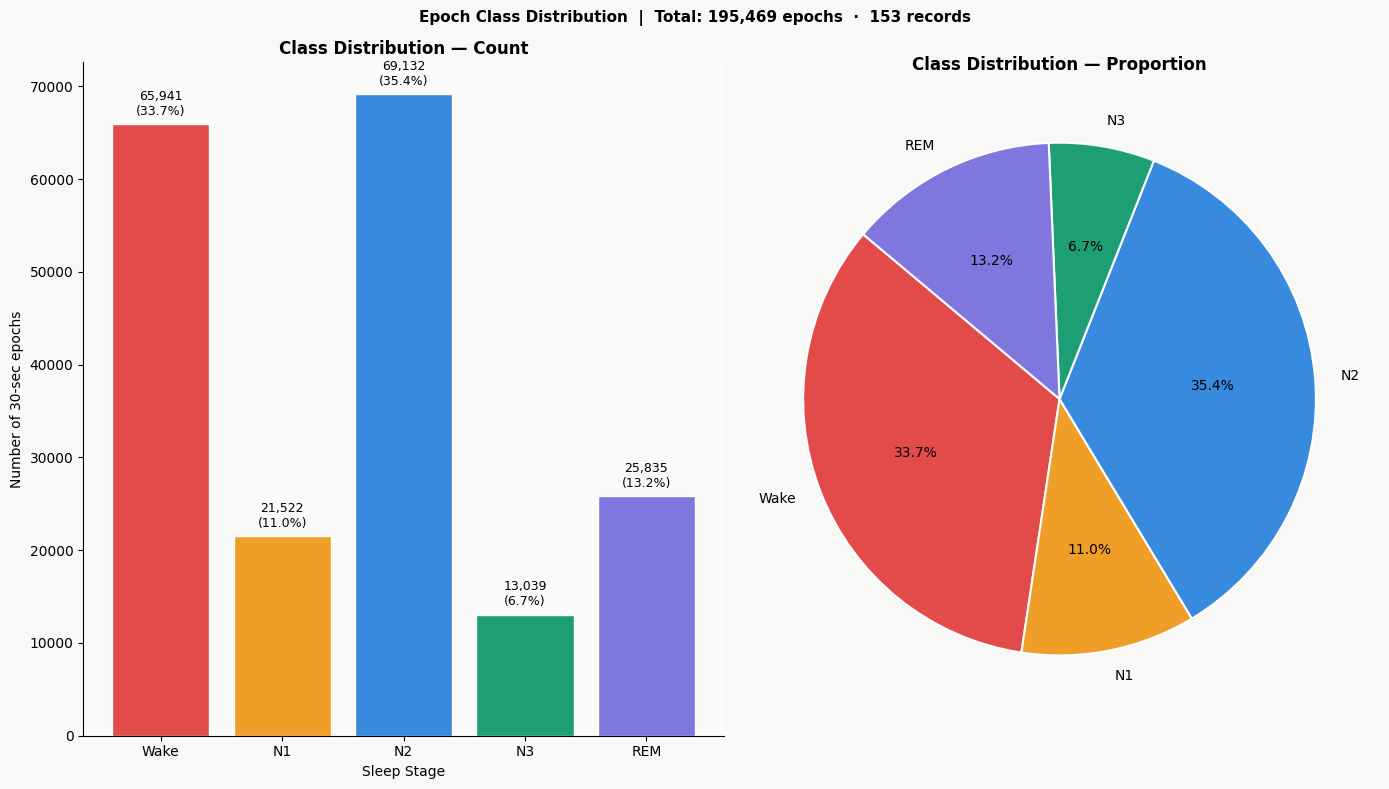

Saved → dataset_class_distribution.png


In [ ]:
# ── Figure 2 : Epoch class distribution (full dataset) ───────────────────────
_counts  = np.array([(labels == s).sum() for s in range(5)])
_total   = _counts.sum()
_pct     = 100 * _counts / _total
_slabels = [STAGE_NAMES[s] for s in range(5)]
_scols   = [COLORS[s] for s in range(5)]

fig2, (ax_bar, ax_pie) = plt.subplots(1, 2, figsize=(14, 8))
fig2.patch.set_facecolor('#f8f8f6')

# ── Left: count bar chart ─────────────────────────────────────────────────────
bars = ax_bar.bar(_slabels, _counts, color=_scols, edgecolor='white')
for bar, cnt, pct in zip(bars, _counts, _pct):
    ax_bar.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + _counts.max()*0.01,
                f'{cnt:,}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=9)
ax_bar.set_title('Class Distribution — Count', fontweight='bold')
ax_bar.set_ylabel('Number of 30-sec epochs')
ax_bar.set_xlabel('Sleep Stage')
ax_bar.spines[['top', 'right']].set_visible(False)
ax_bar.set_facecolor('#fafaf8')


# ── Right: percentage pie chart ───────────────────────────────────────────────
ax_pie.pie(_counts, labels=_slabels, colors=_scols,
           autopct='%1.1f%%', startangle=140,
           wedgeprops={'linewidth': 1.5, 'edgecolor': 'white'},
           textprops={'fontsize': 10})

ax_pie.set_title('Class Distribution — Proportion', fontweight='bold')

fig2.suptitle(f'Epoch Class Distribution  |  Total: {_total:,} epochs  ·  '
              f'{len(np.unique(sids))} records',
              fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'dataset_class_distribution.png'),
            dpi=150, bbox_inches='tight', facecolor=fig2.get_facecolor())
plt.show()
print("Saved → dataset_class_distribution.png")


  Generating CWT scalogram plot...


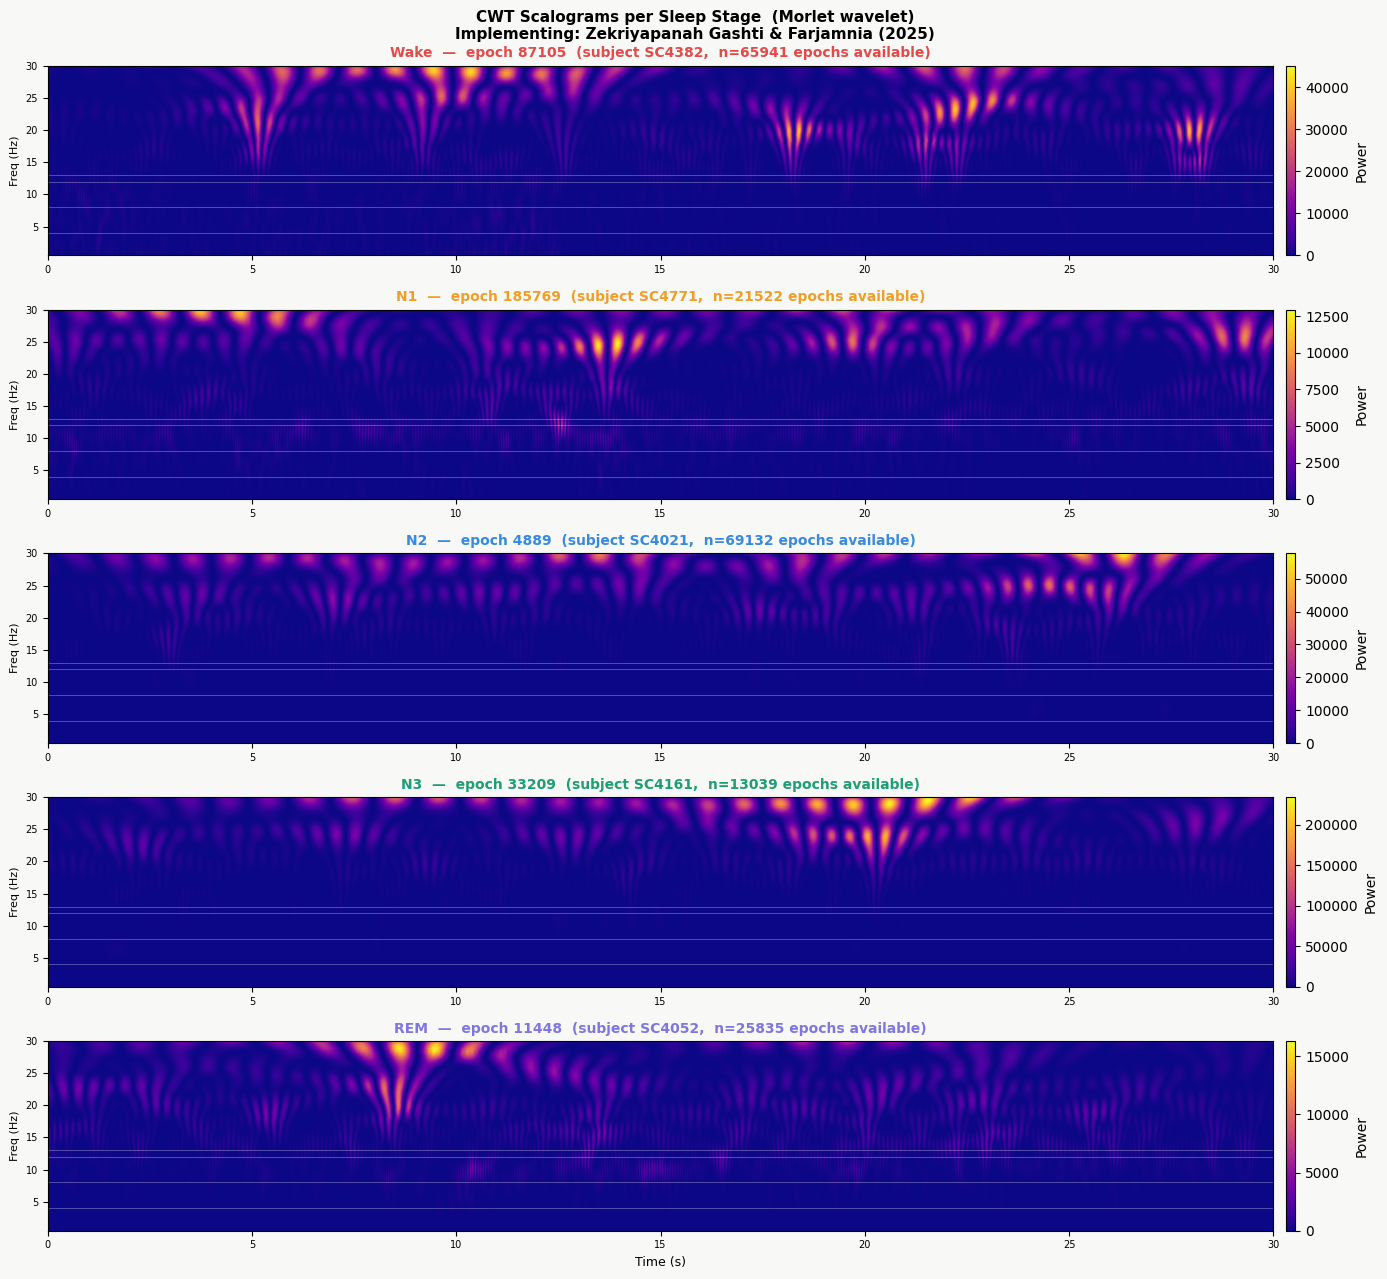

  Saved → .\outputs\cwt_scalograms.png


In [30]:
# ─────────────────────────────────────────────────────────
# CWT SCALOGRAM VISUALISATION (one per stage)
# ─────────────────────────────────────────────────────────
print("\n  Generating CWT scalogram plot...")

dt      = 1.0 / SFREQ
central = pywt.central_frequency(WAVELET)
scales  = np.geomspace(central / (30.0 * dt),
                       central / (0.5  * dt), num=64)

fig, axes = plt.subplots(5, 1, figsize=(14, 13))
fig.patch.set_facecolor('#f8f8f6')

for ax, stage in zip(axes, range(5)):
    # Pick the median-energy epoch for this stage — more representative
    # than [0] which may be a noisy boundary epoch
    stage_idxs = np.where(y == stage)[0]

    if len(stage_idxs) == 0:
        ax.set_title(f'{STAGE_NAMES[stage]} — no epochs found',
                     fontsize=10, color='gray')
        ax.axis('off')
        continue

    stage_epochs  = epochs[stage_idxs].astype(float)
    energies      = np.sum(stage_epochs ** 2, axis=1)
    median_pos    = np.argmin(np.abs(energies - np.median(energies)))
    idx           = stage_idxs[median_pos]
    ep            = epochs[idx].astype(float)
    subject_id    = groups[idx]           # which patient this epoch came from

    coeffs, freqs = pywt.cwt(ep, scales, WAVELET,
                             sampling_period=dt)
    power = np.abs(coeffs) ** 2

    im = ax.imshow(
        power, aspect='auto', origin='lower',
        extent=[0, EPOCH_SEC, freqs[-1], freqs[0]],
        cmap='plasma', interpolation='bilinear'
    )
    ax.set_ylabel('Freq (Hz)', fontsize=8)
    ax.set_title(
        f'{STAGE_NAMES[stage]}  —  epoch {idx}  (subject {subject_id},  '
        f'n={len(stage_idxs)} epochs available)',
        fontsize=10, fontweight='bold', color=COLORS[stage]
    )
    ax.tick_params(labelsize=7)
    for flo, _ in FREQ_BANDS.values():
        ax.axhline(flo, color='white', linewidth=0.4, alpha=0.5)
    plt.colorbar(im, ax=ax, fraction=0.02, pad=0.01, label='Power')

axes[-1].set_xlabel('Time (s)', fontsize=9)
fig.suptitle(
    'CWT Scalograms per Sleep Stage  (Morlet wavelet)\n'
    'Implementing: Zekriyapanah Gashti & Farjamnia (2025)',
    fontsize=11, fontweight='bold'
)
plt.tight_layout()
out_path = os.path.join(OUT_DIR, 'cwt_scalograms.png')
plt.savefig(out_path, dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()
print(f"  Saved → {out_path}")

Checking the nan and inf values

In [31]:
nan_count = np.isnan(X).sum()
inf_count = np.isinf(X).sum()

print(f"Number of NaN values in X: {nan_count}")
print(f"Number of infinite values in X: {inf_count}")

if nan_count == 0 and inf_count == 0:
    print("No non-finite values found in X.")
else:
    print("Non-finite values detected. They need to be handled before scaling.")

Number of NaN values in X: 0
Number of infinite values in X: 0
No non-finite values found in X.


In [32]:
# Replace NaN values with the mean of their respective columns
# Also replace inf values with NaN first, then handle all NaNs
X_cleaned = X.copy()
X_cleaned[np.isinf(X_cleaned)] = np.nan

for i in range(X_cleaned.shape[1]):
    col_mean = np.nanmean(X_cleaned[:, i])
    # Only replace if the mean is a finite number, otherwise, replace with 0 or a sensible default
    if np.isfinite(col_mean):
        X_cleaned[:, i] = np.nan_to_num(X_cleaned[:, i], nan=col_mean, posinf=col_mean, neginf=col_mean)
    else:
        # If the whole column is NaN/inf, replace with 0
        X_cleaned[:, i] = np.nan_to_num(X_cleaned[:, i], nan=0.0, posinf=0.0, neginf=0.0)

# Verify that there are no more non-finite values
final_nan_count = np.isnan(X_cleaned).sum()
final_inf_count = np.isinf(X_cleaned).sum()
print(f"After cleaning: NaN count = {final_nan_count}, Inf count = {final_inf_count}")

# X_new = X_cleaned # Update X to the cleaned version


After cleaning: NaN count = 0, Inf count = 0


Train test spilt the data 80:20

In [ ]:
# spliting the data to 80:20
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler

# Load saved features
X      = np.load(os.path.join(OUT_DIR, 'X_features.npy'))
y      = np.load(os.path.join(OUT_DIR, 'y_labels.npy'))
sids   = np.load(os.path.join(OUT_DIR, 'groups_sids.npy'))

# ── Train/Test split — group-aware (no subject leakage) ──
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=sids))

np.save(os.path.join(OUT_DIR, 'train_idx.npy'), train_idx)
np.save(os.path.join(OUT_DIR, 'test_idx.npy'),   test_idx)

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

print(f"  Train: {len(train_idx)} epochs  —  {len(np.unique(sids[train_idx]))} recording")
print(f"  Test : {len(test_idx)} epochs  —  {len(np.unique(sids[test_idx]))} recording")


  Train: 156942 epochs  —  122 recording
  Test : 38527 epochs  —  31 recording


Z-score standarization for dataset

In [ ]:
# ── Z-score standardisation ───────────────────────────────
# Fit ONLY on train → transform both train and test
# Prevents data leakage from test distribution into training
scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)   # fit + transform
X_test  = scaler.transform(X_test)        # transform only ✓

print(f"\n  After standardisation:")
print(f"    X_train mean ≈ {X_train.mean():.4f}  std ≈ {X_train.std():.4f}")
print(f"    X_test  mean ≈ {X_test.mean():.4f}  std ≈ {X_test.std():.4f}")

# Save for later use
np.save(os.path.join(OUT_DIR, 'X_train.npy'), X_train)
np.save(os.path.join(OUT_DIR, 'X_test.npy'),  X_test)
np.save(os.path.join(OUT_DIR, 'y_train.npy'), y_train)
np.save(os.path.join(OUT_DIR, 'y_test.npy'),  y_test)

joblib.dump(scaler, os.path.join(OUT_DIR, 'scaler.pkl'))  # save for inference
print(f"\n  Saved splits + scaler → {OUT_DIR}")


  After standardisation:
    X_train mean ≈ 0.0000  std ≈ 1.0000
    X_test  mean ≈ -0.0248  std ≈ 0.9401

  Saved splits + scaler → .\outputs


## Section 1 — Feature Extracted + XGBoost Model


K-fold cross validation

In [ ]:
# XGBoost CLASSIFIER  (5-fold stratified CV)
print("\n XGBoost Training (5-fold CV on train set)")


# Load the properly split + scaled data from previous step
X_train = np.load(os.path.join(OUT_DIR, 'X_train.npy'))
X_test  = np.load(os.path.join(OUT_DIR, 'X_test.npy'))
y_train = np.load(os.path.join(OUT_DIR, 'y_train.npy'))
y_test  = np.load(os.path.join(OUT_DIR, 'y_test.npy'))

# ── Class weights to handle imbalance (Wake >> N1) ────────
class_counts  = np.bincount(y_train)
class_weights = len(y_train) / (len(np.unique(y_train)) * class_counts)
sample_weights = np.array([class_weights[yi] for yi in y_train])

# ── XGBoost model ─────────────────────────────────────────
XGB_PARAMS = dict(
    n_estimators     = 200,
    max_depth        = 6,
    learning_rate    = 0.1,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    eval_metric      = 'mlogloss',
    use_label_encoder= False,
    random_state     = 42,
    n_jobs           = -1,
)

# ── 5-fold CV on train set only ───────────────────────────
cv        = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
all_preds_xgb = np.zeros_like(y_train)

fold_accs, fold_f1s, fold_kappas = [], [], []
fold_logloss_train, fold_logloss_val = [], []

for fold, (tr_idx, val_idx) in enumerate(cv.split(X_train, y_train)):
    X_tr,  X_val = X_train[tr_idx], X_train[val_idx]
    y_tr,  y_val = y_train[tr_idx], y_train[val_idx]
    sw_tr        = sample_weights[tr_idx]

    fold_model = xgb.XGBClassifier(**XGB_PARAMS)
    fold_model.fit(
        X_tr, y_tr,
        sample_weight = sw_tr,
        eval_set      = [(X_tr, y_tr), (X_val, y_val)],
        verbose       = False,
    )

    preds = fold_model.predict(X_val)
    all_preds_xgb[val_idx] = preds

    acc_f   = accuracy_score(y_val, preds)
    f1_f    = f1_score(y_val, preds, average="macro")
    kappa_f = cohen_kappa_score(y_val, preds)
    fold_accs.append(acc_f)
    fold_f1s.append(f1_f)
    fold_kappas.append(kappa_f)

    res = fold_model.evals_result()
    fold_logloss_train.append(res["validation_0"]["mlogloss"])
    fold_logloss_val.append(res["validation_1"]["mlogloss"])

    print(f"  Fold {fold+1}/5 | {acc_f*100:>6.2f}% | {f1_f:>8.4f} | {kappa_f:>7.4f}")

print(f"  {'-'*38}")
print(f"  {'Mean':>5} | {np.mean(fold_accs)*100:>6.2f}% | "
      f"{np.mean(fold_f1s):>8.4f} | {np.mean(fold_kappas):>7.4f}")
print(f"  {'±Std':>5} | {np.std(fold_accs)*100:>6.2f}%   | "
      f"{np.std(fold_f1s):>8.4f} | {np.std(fold_kappas):>7.4f}")

# Keep final fold model as xgb_model for retraining
xgb_model = fold_model



 XGBoost Training (5-fold CV on train set)
  Fold 1/5 |  76.31% |   0.7139 |  0.6825
  Fold 2/5 |  76.48% |   0.7187 |  0.6850
  Fold 3/5 |  76.46% |   0.7213 |  0.6848
  Fold 4/5 |  76.12% |   0.7138 |  0.6802
  Fold 5/5 |  76.27% |   0.7157 |  0.6825
  --------------------------------------
   Mean |  76.33% |   0.7167 |  0.6830
   ±Std |   0.13%   |   0.0029 |  0.0018


### Per-fold accuracy, macro F1 and Cohen's κ

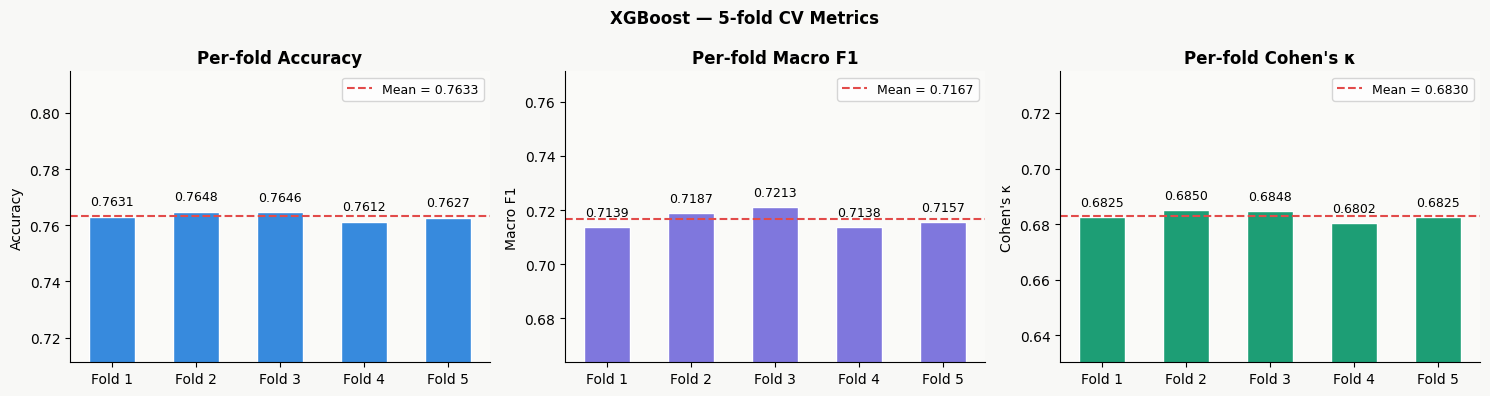

Saved → xgb_cv_fold_metrics.png


In [36]:
# ── Per-fold metric bar charts — XGBoost CV ──────────────────────────────────

fold_labels = [f"Fold {i+1}" for i in range(5)]
x = np.arange(5)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.patch.set_facecolor("#f8f8f6")

metric_data = [
    (fold_accs,   "Accuracy",   "#378ADD"),
    (fold_f1s,    "Macro F1",   "#7F77DD"),
    (fold_kappas, "Cohen's κ",  "#1D9E75"),
]
for ax, (vals, label, color) in zip(axes, metric_data):
    ax.set_facecolor("#fafaf8")
    bars = ax.bar(fold_labels, vals, color=color, edgecolor="white", width=0.55)
    mean_v = np.mean(vals)
    ax.axhline(mean_v, color="#E24B4A", linewidth=1.5,
               linestyle="--", label=f"Mean = {mean_v:.4f}")
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                f"{v:.4f}", ha="center", va="bottom", fontsize=9)
    ax.set_title(f"Per-fold {label}", fontweight="bold")
    ax.set_ylabel(label)
    ax.set_ylim(max(0, min(vals) - 0.05), min(1, max(vals) + 0.05))
    ax.legend(fontsize=9)
    ax.spines[["top","right"]].set_visible(False)

plt.suptitle("XGBoost — 5-fold CV Metrics", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "xgb_cv_fold_metrics.png"),
            dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()
print("Saved → xgb_cv_fold_metrics.png")

### Per-fold mlogloss curves (train vs validation)

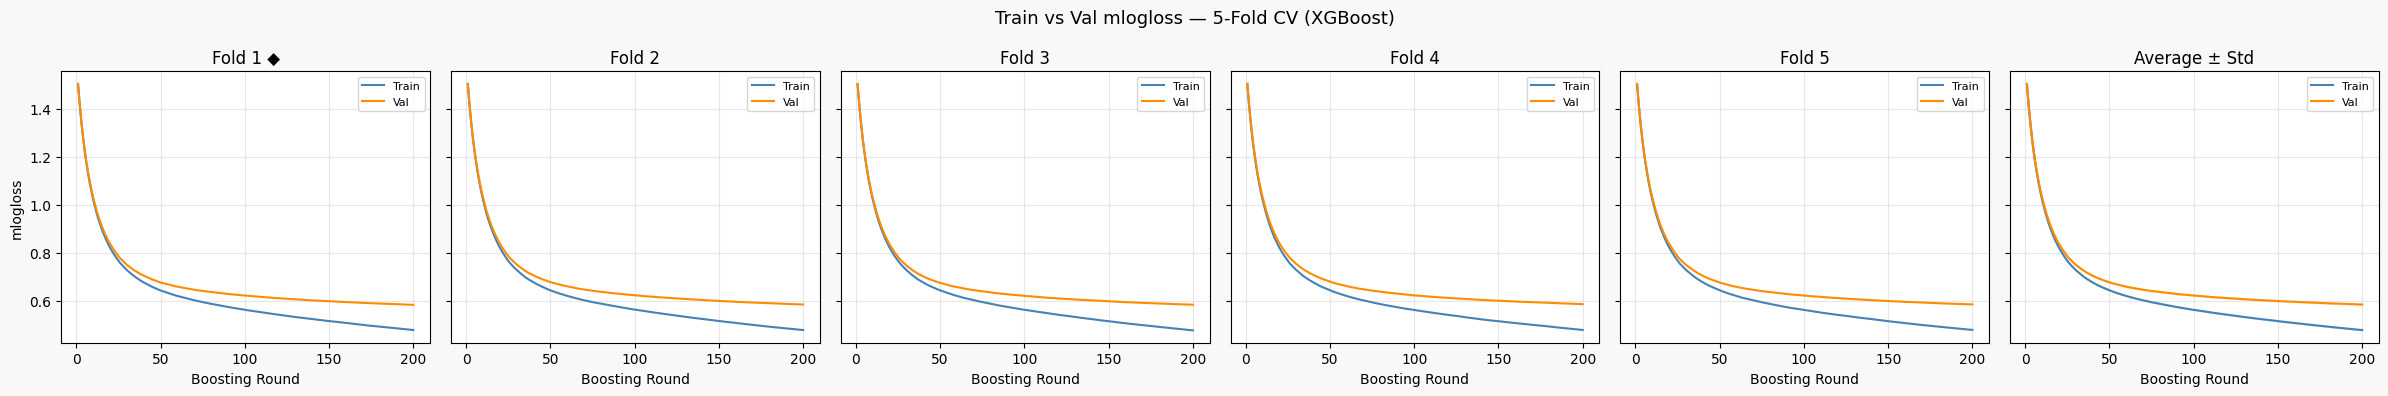

Saved → .\outputs\03_xgb_fold_loss_curves.png


In [37]:
# ── XGBoost: Per-fold mlogloss curves + average ──────────────────────────────
N_FOLDS  = 5
n_rounds = len(fold_logloss_train[0])          # = 200 (n_estimators)
rounds   = np.arange(1, n_rounds + 1)

# Best fold = lowest final validation mlogloss
best_fold_xgb = int(np.argmin([vl[-1] for vl in fold_logloss_val])) + 1

n_plots = N_FOLDS + 1
fig, axes = plt.subplots(1, n_plots, figsize=(4 * n_plots, 4), sharey=True)
fig.patch.set_facecolor('#f8f8f6')

# ── One panel per fold ────────────────────────────────────────────────────────
for i, ax in enumerate(axes[:N_FOLDS]):
    ax.plot(rounds, fold_logloss_train[i], label='Train', color='steelblue')
    ax.plot(rounds, fold_logloss_val[i], label='Val',   color='darkorange')
    marker = ' ◆' if (i + 1) == best_fold_xgb else ''
    ax.set_title(f'Fold {i+1}{marker}')
    ax.set_xlabel('Boosting Round')
    if i == 0:
        ax.set_ylabel('mlogloss')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

# ── Average ± Std panel ───────────────────────────────────────────────────────
ax_avg       = axes[-1]
train_matrix = np.array(fold_logloss_train)    # (5, 200)
val_matrix   = np.array(fold_logloss_val)    # (5, 200)

for matrix, color, label in [
    (train_matrix, 'steelblue',  'Train'),
    (val_matrix,   'darkorange', 'Val'),
]:
    mean_ = matrix.mean(axis=0)
    std_  = matrix.std(axis=0)
    ax_avg.plot(rounds, mean_, color=color, label=label)
    ax_avg.fill_between(rounds, mean_ - std_, mean_ + std_,
                        alpha=0.2, color=color)

ax_avg.set_title('Average ± Std')
ax_avg.set_xlabel('Boosting Round')
ax_avg.legend(fontsize=8)
ax_avg.grid(alpha=0.3)

fig.suptitle('Train vs Val mlogloss — 5-Fold CV (XGBoost)', fontsize=13)
plt.tight_layout()
out_path = os.path.join(OUT_DIR, '03_xgb_fold_loss_curves.png')
plt.savefig(out_path, dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print(f"Saved → {out_path}")

### Cross-validation summary + classification report

In [38]:
# Landis & Koch (1977) κ interpretation
def kappa_label(k):
    if k >= 0.80: return 'Near-perfect'
    if k >= 0.60: return 'Substantial'
    if k >= 0.40: return 'Moderate'
    if k >= 0.20: return 'Fair'
    return 'Slight / Poor'

In [39]:
# ── CV summary + classification report ───────────────────────────────────────
cv_acc_xgb    = accuracy_score(y_train, all_preds_xgb)
cv_f1_xgb     = f1_score(y_train, all_preds_xgb, average="macro")
cv_kappa_xgb  = cohen_kappa_score(y_train, all_preds_xgb)

print("XGBoost — Cross-Validation Summary (5-fold, train set)")
print("=" * 56)
print(f"  CV Accuracy  : {cv_acc_xgb*100:.2f}%")
print(f"  CV Macro F1  : {cv_f1_xgb:.4f}")
print(f"  CV Cohen's κ : {cv_kappa_xgb:.4f}  ({kappa_label(cv_kappa_xgb)})")
print(f"  Per-fold Acc : {np.mean(fold_accs)*100:.2f}% ± {np.std(fold_accs)*100:.2f}%")
print(f"  Per-fold F1  : {np.mean(fold_f1s):.4f} ± {np.std(fold_f1s):.4f}")
print(f"  Per-fold κ   : {np.mean(fold_kappas):.4f} ± {np.std(fold_kappas):.4f}")
print()
tnames = [STAGE_NAMES[s] for s in range(5)]
print("  Classification report (aggregated CV predictions on train set):")
print(classification_report(y_train, all_preds_xgb,
                             target_names=tnames, digits=4))

XGBoost — Cross-Validation Summary (5-fold, train set)
  CV Accuracy  : 76.33%
  CV Macro F1  : 0.7167
  CV Cohen's κ : 0.6830  (Substantial)
  Per-fold Acc : 76.33% ± 0.13%
  Per-fold F1  : 0.7167 ± 0.0029
  Per-fold κ   : 0.6830 ± 0.0018

  Classification report (aggregated CV predictions on train set):
              precision    recall  f1-score   support

        Wake     0.9412    0.8633    0.9006     53492
          N1     0.3763    0.5200    0.4366     17474
          N2     0.8866    0.7312    0.8014     55651
          N3     0.6962    0.9157    0.7910      9797
         REM     0.5957    0.7240    0.6536     20528

    accuracy                         0.7633    156942
   macro avg     0.6992    0.7508    0.7167    156942
weighted avg     0.7985    0.7633    0.7746    156942



CONFUSION MATRIX for cross Validation

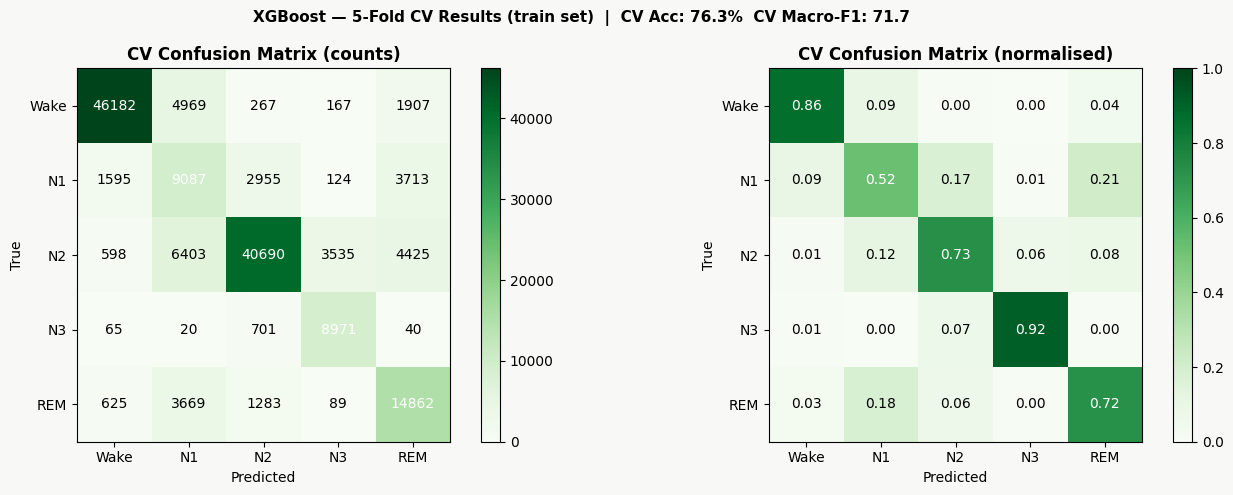

  CV Accuracy  : 76.33%
  CV Macro-F1  : 71.67%
  Saved → .\outputs\03a_confusion_matrix_cv.png


In [ ]:
# ── CONFUSION MATRIX — Cross-Validation (train set) ──────
cm_cv      = confusion_matrix(y_train, all_preds_xgb)
cm_cv_norm = cm_cv.astype(float) / cm_cv.sum(axis=1, keepdims=True)

target_names = [STAGE_NAMES[s] for s in sorted(np.unique(y_train))]

def fmt_counts(v): return str(int(v))
def fmt_norm(v):   return f'{v:.2f}'

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#f8f8f6')

for ax, data, title, fmt in zip(
        axes,
        [cm_cv,       cm_cv_norm],
        ['CV Confusion Matrix (counts)', 'CV Confusion Matrix (normalised)'],
        [fmt_counts,  fmt_norm]):

    vmax = 1.0 if data is cm_cv_norm else None
    im   = ax.imshow(data, cmap='Greens', vmin=0, vmax=vmax)  # ← Oranges to distinguish from test

    ax.set_title(title, fontweight='bold')
    ax.set_xticks(range(len(target_names)))
    ax.set_yticks(range(len(target_names)))
    ax.set_xticklabels(target_names)
    ax.set_yticklabels(target_names)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')

    for i in range(len(target_names)):
        for j in range(len(target_names)):
            ax.text(j, i,
                    fmt(data[i, j]),
                    ha='center', va='center',
                    fontsize=10,
                    color='white' if cm_cv_norm[i, j] > 0.5 else 'black')

    plt.colorbar(im, ax=ax)

# CV metrics
cv_acc      = accuracy_score(y_train, all_preds_xgb)
cv_macro_f1 = f1_score(y_train, all_preds_xgb, average='macro')

fig.suptitle(
    f'XGBoost — 5-Fold CV Results (train set)  |  '
    f'CV Acc: {cv_acc*100:.1f}%  CV Macro-F1: {cv_macro_f1*100:.1f}',
    fontsize=11, fontweight='bold'
)
plt.tight_layout()

out_path = os.path.join(OUT_DIR, '03a_confusion_matrix_cv.png')
plt.savefig(out_path, dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()
print(f"  CV Accuracy  : {cv_acc*100:.2f}%")
print(f"  CV Macro-F1  : {cv_macro_f1*100:.2f}%")
print(f"  Saved → {out_path}")

Test model

In [41]:
# ── Final model — retrain on full train set ───────────────
print("\n  Retraining on full training set...")
xgb_model.fit(X_train, y_train, sample_weight=sample_weights, verbose=False)



  Retraining on full training set...


,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.8
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegresso

Test evaluation

In [42]:
# ── Evaluate on held-out test set ────────────────────────
y_pred_xgb     = xgb_model.predict(X_test)

test_acc_xgb     = accuracy_score(y_test, y_pred_xgb)
test_macro_f1_xgb = f1_score(y_test, y_pred_xgb, average='macro')
test_kappa_xgb   = cohen_kappa_score(y_test, y_pred_xgb)

print("XGBoost Baseline — Held-out Test Set")
print("=" * 48)
print(f"  Accuracy  : {test_acc_xgb*100:.4f}%")
print(f"  Macro F1  : {test_macro_f1_xgb:.4f}")
print(f"  Cohen's κ : {test_kappa_xgb:.4f}  ({kappa_label(test_kappa_xgb)})")
print()
print(f"\n  Per-class report (test set):")
target_names = [STAGE_NAMES[s] for s in sorted(np.unique(y_test))]
print(classification_report(y_test, y_pred_xgb,
                             target_names=target_names, digits=4))

XGBoost Baseline — Held-out Test Set
  Accuracy  : 73.8729%
  Macro F1  : 0.7026
  Cohen's κ : 0.6547  (Substantial)


  Per-class report (test set):
              precision    recall  f1-score   support

        Wake     0.9182    0.8074    0.8592     12449
          N1     0.2987    0.4859    0.3699      4048
          N2     0.8699    0.7413    0.8005     13481
          N3     0.8244    0.8686    0.8459      3242
         REM     0.5966    0.6846    0.6375      5307

    accuracy                         0.7387     38527
   macro avg     0.7015    0.7176    0.7026     38527
weighted avg     0.7840    0.7387    0.7556     38527



Best test mlogloss : 0.5856  at round 200
Final test mlogloss: 0.5856


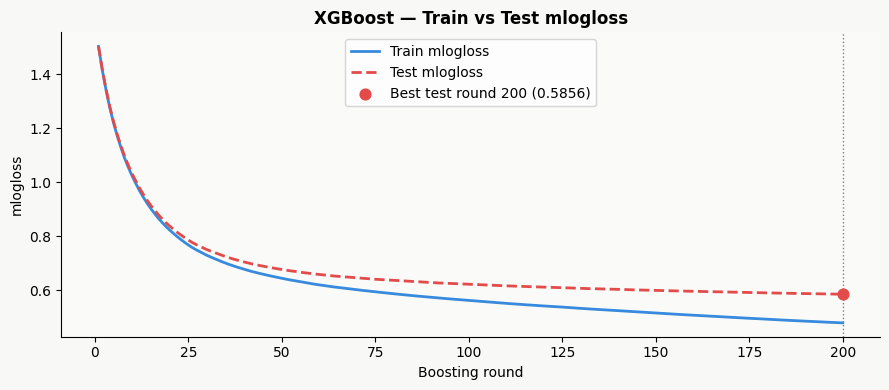

In [43]:
# ── Plot ──────────────────────────────────────────────────────────────────────
train_loss = xgb_model.evals_result()['validation_0']['mlogloss']
test_loss  = xgb_model.evals_result()['validation_1']['mlogloss']
best_round = int(np.argmin(test_loss))

fig, ax = plt.subplots(figsize=(9, 4))
fig.patch.set_facecolor('#f8f8f6')
ax.set_facecolor('#fafaf8')

rounds = range(1, len(train_loss) + 1)
ax.plot(rounds, train_loss, color='#378ADD', linewidth=2, label='Train mlogloss')
ax.plot(rounds, test_loss,  color='#E24B4A', linewidth=2,
        linestyle='--', label='Test mlogloss')

# Mark best test round
best_round = int(np.argmin(test_loss))
ax.axvline(best_round + 1, color='gray', linewidth=1, linestyle=':')
ax.scatter(best_round + 1, test_loss[best_round],
           color='#E24B4A', zorder=5, s=60,
           label=f'Best test round {best_round+1} ({test_loss[best_round]:.4f})')

ax.set_xlabel('Boosting round')
ax.set_ylabel('mlogloss')
ax.set_title('XGBoost — Train vs Test mlogloss', fontweight='bold')
ax.legend()
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()

out_path = os.path.join(OUT_DIR, 'xgb_train_test_loss.png')
plt.savefig(out_path, dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())

print(f"Best test mlogloss : {min(test_loss):.4f}  at round {best_round+1}")
print(f"Final test mlogloss: {test_loss[-1]:.4f}")

CONFUSION MATRIX for test

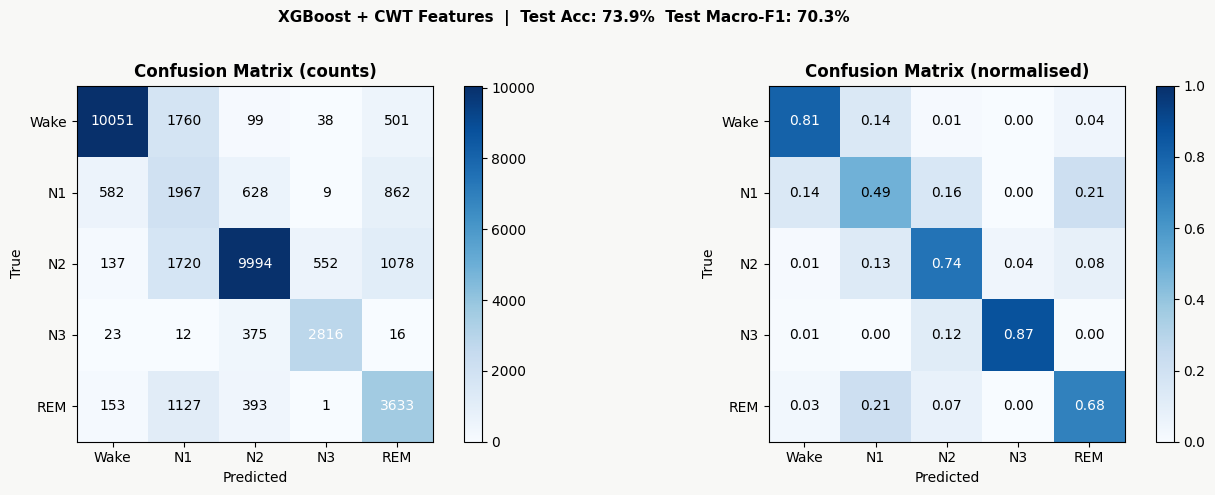

  Saved → .\outputs\03b_confusion_matrix.png


In [44]:
# ── CONFUSION MATRIX PLOT ─────────────────────────────────

cm_xgb  = confusion_matrix(y_test, y_pred_xgb)
cm_norm_xgb = cm_xgb.astype(float) / cm_xgb.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#f8f8f6')

def fmt_counts(v):  return str(int(v))
def fmt_norm(v):    return f'{v:.2f}'

for ax, data, title, fmt in zip(
        axes,
        [cm_xgb,       cm_norm_xgb],
        ['Confusion Matrix (counts)', 'Confusion Matrix (normalised)'],
        [fmt_counts,    fmt_norm]):

    vmax = 1.0 if data is cm_norm_xgb else None
    im   = ax.imshow(data, cmap='Blues', vmin=0, vmax=vmax)

    ax.set_title(title, fontweight='bold')
    ax.set_xticks(range(len(target_names)))
    ax.set_yticks(range(len(target_names)))
    ax.set_xticklabels(target_names)
    ax.set_yticklabels(target_names)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')

    for i in range(len(target_names)):
        for j in range(len(target_names)):
            ax.text(j, i,
                    fmt(data[i, j]),          # ← uses correct fmt per matrix
                    ha='center', va='center',
                    fontsize=10,
                    color='white' if cm_norm_xgb[i, j] > 0.5 else 'black')

    plt.colorbar(im, ax=ax)

fig.suptitle(
    f'XGBoost + CWT Features  |  '
    f'Test Acc: {test_acc_xgb*100:.1f}%  '
    f'Test Macro-F1: {test_macro_f1_xgb*100:.1f}%\n',
    fontsize=11, fontweight='bold'
)
plt.tight_layout()
out_path = os.path.join(OUT_DIR, '03b_confusion_matrix.png')
plt.savefig(out_path, dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()
print(f"  Saved → {out_path}")

feature importance for test

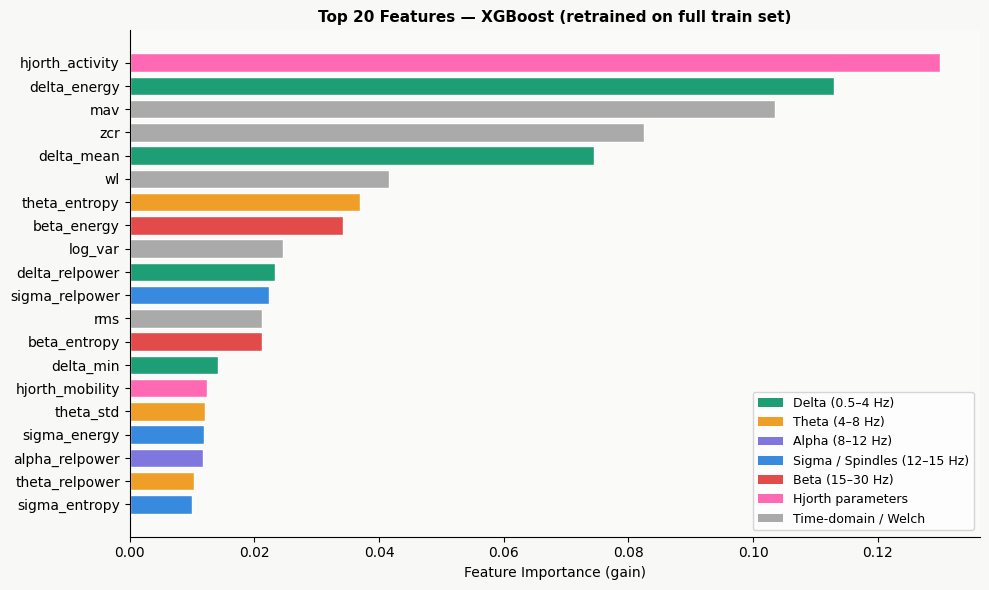

  Saved → .\outputs\03c_feature_importance.png


In [ ]:
# FEATURE IMPORTANCE PLOT

# ── FEATURE IMPORTANCE PLOT ───────────────────────────────
importances = xgb_model.feature_importances_
top_k   = 20
top_idx = np.argsort(importances)[-top_k:][::-1]

# ← extended color map to cover all feature types
feature_colors = {
    # CWT band features
    'delta' : '#1D9E75',
    'theta' : '#EF9F27',
    'alpha' : '#7F77DD',
    'sigma' : '#378ADD',
    'beta'  : '#E24B4A',
    # Time-domain features
    'zcr'            : '#aaaaaa',
    'rms'            : '#aaaaaa',
    'mav'            : '#aaaaaa',
    'wl'             : '#aaaaaa',
    'log'            : '#aaaaaa',   # log_var → prefix 'log'
    'hjorth'         : '#FF69B4',   # hjorth_* → prefix 'hjorth'
    'variance'       : '#aaaaaa',
    'skewness'       : '#aaaaaa',
    'kurtosis'       : '#aaaaaa',
}

def get_color(name):
    prefix = name.split('_')[0]
    return feature_colors.get(prefix, '#cccccc')

bar_colors = [get_color(feature_names[i]) for i in top_idx]

fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor('#f8f8f6')
ax.barh(
    [feature_names[i] for i in top_idx],
    importances[top_idx],
    color=bar_colors, edgecolor='white'
)
ax.set_xlabel('Feature Importance (gain)', fontsize=10)
ax.set_title(f'Top {top_k} Features — XGBoost (retrained on full train set)',
             fontsize=11, fontweight='bold')
ax.set_facecolor('#fafaf8')
ax.spines[['top', 'right']].set_visible(False)
ax.invert_yaxis()

legend_elements = [
    Patch(facecolor=c, label=l) for c, l in [
        ('#1D9E75', 'Delta (0.5–4 Hz)'),
        ('#EF9F27', 'Theta (4–8 Hz)'),
        ('#7F77DD', 'Alpha (8–12 Hz)'),
        ('#378ADD', 'Sigma / Spindles (12–15 Hz)'),
        ('#E24B4A', 'Beta (15–30 Hz)'),
        ('#FF69B4', 'Hjorth parameters'),
        ('#aaaaaa', 'Time-domain / Welch'),
    ]
]
ax.legend(handles=legend_elements, fontsize=9, loc='lower right')
plt.tight_layout()

out_path = os.path.join(OUT_DIR, '03c_feature_importance.png')
plt.savefig(out_path, dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()
print(f"  Saved → {out_path}")

Resultt for test

In [46]:

print("\n RESULTS")

# CV performance (on train set)
cv_acc_xgb      = accuracy_score(y_train, all_preds_xgb)
cv_macro_f1_xgb = f1_score(y_train, all_preds_xgb, average='macro')
cv_kappa_xgb   = cohen_kappa_score(y_train, all_preds_xgb)

print(f"\n  ── Cross-Validation (train set) ──")
print(f"  CV mean ± std    : {np.mean(fold_accs)*100:.2f}% ± {np.std(fold_accs)*100:.2f}%")
print(f"  CV Accuracy      : {cv_acc_xgb*100:.2f}%")
print(f"  CV Macro F1      : {cv_macro_f1_xgb*100:.2f}%")
print(f"  CV Cohen's κ : {cv_kappa_xgb:.4f}  ({kappa_label(cv_kappa_xgb)})")


print(f"\n  ── Held-out Test Set ──")
print(f"  Test Accuracy    : {test_acc_xgb*100:.2f}%")
print(f"  Test Macro F1    : {test_macro_f1_xgb*100:.2f}%")
print(f"  Cohen's κ : {test_kappa_xgb:.4f}  ({kappa_label(test_kappa_xgb)})")



 RESULTS

  ── Cross-Validation (train set) ──
  CV mean ± std    : 76.33% ± 0.13%
  CV Accuracy      : 76.33%
  CV Macro F1      : 71.67%
  CV Cohen's κ : 0.6830  (Substantial)

  ── Held-out Test Set ──
  Test Accuracy    : 73.87%
  Test Macro F1    : 70.26%
  Cohen's κ : 0.6547  (Substantial)


In [ ]:
# save the model
joblib.dump(xgb_model, os.path.join(OUT_DIR, 'xgb_model.pkl'))
print(f"\n  Saved model → {OUT_DIR}")


  Saved model → .\outputs


In [48]:
# SAVE FEATURES (for reuse in deep learning step)

np.save(os.path.join(OUT_DIR, 'X_cwt_features.npy'), X)
np.save(os.path.join(OUT_DIR, 'y_labels.npy'), y)

print("\n" + "=" * 58)
print("  DONE")
print(f"  All outputs saved to:\n  {OUT_DIR}")
print("=" * 58)


  DONE
  All outputs saved to:
  .\outputs
